In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
hbar=h/(2*np.pi)
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
me=cons.m_e.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2


In [2]:
default_args = {}
default_args['figsize'] = (4,4)
default_args['filename_data'] = '../output/example_free_free_tde.npz'
default_args['filename_plot'] = None
default_args['stokes_q'] = False
default_args['stokes_u'] = False
default_args['stokes_v'] = False
default_args['name'] = None
default_args['frequency_num'] = None
default_args['refinement_level'] = False
default_args['width'] = None
default_args['mass'] = None
default_args['distance'] = None
default_args['axes'] = None
default_args['max_level'] = None
default_args['vmin'] = None
default_args['vmax'] = None
default_args['cmap'] = None
default_args['notex'] = False
default_args['fontsize'] = None

In [3]:
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["figure.dpi"] = 100

In [4]:
temp=(100*G*Mbh/c**2)*u.cgs.cm
print(temp)
print(temp.to(u.pc))

44298751141503.734 cm
1.4356247524763523e-05 pc


In [73]:
v0=0.001
mu=0.5
rho0=1.543e-3
P0 = rho0*v0*v0*c*c
print(P0)
print(mu*mp*v0*v0*c*c/kB)

1386779240790.9097
5444097.725001525


In [9]:
(2.998e+07)/c

0.00100002515740406

In [4]:
((288*me*((4.8e-10)**2)*((0.8853)**3)*((4*np.pi)**(4/3))*((5.29e-9)**3)/((3*1.66e-24)**(4/3)))**(5/2))/(15*hbar*hbar*hbar*(np.pi**2)*me)

4.200804832009859e+16

In [7]:
9.478e9/1.158e11

0.08184801381692573

In [2]:
hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc45_ph90.npz')

In [3]:
print(hf['emission'])

[[[7.62294810e-042 1.77065521e-041 6.43518568e-041 ... 9.42063549e-040
   4.89366696e-040 2.11871618e-040]
  [3.77607473e-041 7.19946840e-041 1.12621582e-040 ... 4.23940169e-040
   6.68240597e-040 3.76803189e-040]
  [1.73174950e-040 9.73291206e-041 6.06246325e-041 ... 7.75966120e-041
   4.13489645e-040 9.57617715e-040]
  ...
  [7.06990683e-042 6.74395000e-042 6.49761141e-042 ... 3.85936413e-042
   3.87653616e-042 3.93667427e-042]
  [5.94093991e-042 5.27504150e-042 5.12665106e-042 ... 4.41557216e-042
   4.43443160e-042 4.36826242e-042]
  [4.82588307e-042 4.25121516e-042 3.82143306e-042 ... 4.98638604e-042
   5.34413650e-042 5.86008062e-042]]

 [[1.62196599e-042 3.77442522e-042 1.37384508e-041 ... 2.02530150e-040
   1.04540468e-040 4.52334326e-041]
  [8.05371253e-042 1.53637832e-041 2.40603284e-041 ... 9.06699662e-041
   1.43331839e-040 8.04005321e-041]
  [3.70199341e-041 2.07795992e-041 1.29344878e-041 ... 1.64893587e-041
   8.84162796e-041 2.04808574e-040]
  ...
  [1.47794464e-042 1.41

In [19]:
(c*3.335e-08)**2*mu*mp

1.0031875129470097e-18

In [20]:
6.553e6*kB

9.047392897e-10

In [150]:
def j_I(T,nu,ne,ni):
    #1/kBT is like 4.39e13
    #the exponent keeps going to 0
    return (16*np.exp(6)/(3*me*c**3))*np.sqrt(1/me)*np.sqrt(2*np.pi/(3*kB*T))*(ne*ni)*np.exp(-h*nu/(kB*T))*(nu**(-2))

In [151]:
def alpha_I(T,nu,ne,ni):
    return (4*np.exp(6)/(3*me*c*h))*np.sqrt(1/me)*np.sqrt(2*np.pi/(3*kB*T))*ne*ni*(1-np.exp(-h*nu/(kB*T)))*(nu**(-2))

In [178]:
#assuming optically thick
def I_nu(T,nu,ne,ni):
    return (nu**3)*j_I(T,nu,ne,ni)/alpha_I(T,nu,ne,ni)
def nuFnu(T,nu,ne,ni,dist,mass):
    gg_msun = 1.32712440018e26
    rg = gg_msun * mass / c ** 2
    return nu*np.nanmean(I_nu(T,nu,ne,ni))*4*np.pi*((dist*rg)**2)

In [179]:
arguments = {'data_file': '../data/input.cbdisk.out1.01637_float32.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)

(768, 512)


In [81]:
arguments = {'data_file': '../data/input.cbdisk.out1.01637_float32.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)

(768, 512)


In [180]:
rho0=1.543e-3
kT = mu*mp*(v0**2)*(c**2)*(press/rho)
T = kT/kB

In [181]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6

anaI = I_nu(np.average(T),frequencies[freq],np.average((rho*rho0)/(mu*mp)),np.average((rho*rho0)/(mu*mp)))

/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: overflow encountered in multiply
  after removing the cwd from sys.path.
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in multiply
  after removing the cwd from sys.path.


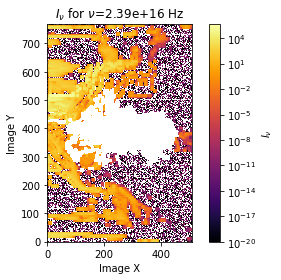

In [182]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6

anaI = I_nu(T,frequencies[freq],(rho*rho0)/(mu*mp),(rho*rho0)/(mu*mp))
minVal = 1e-20
anaI[anaI<minVal]=minVal

plt.imshow(anaI,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('$I_\\nu$ for $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

In [184]:
nuFnu(np.average(T),2.39e16,np.average((rho*1.543e-3)/(mu*mp)),np.average((rho*1.543e-3)/(mu*mp)),1600,2e7)

5.0578772836022926e+51

In [8]:
hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc45.npz')

In [11]:
list(hf.keys())

['mass_msun',
 'width',
 'frequency',
 'adaptive_num_levels',
 'I_nu',
 'emission',
 'tau']

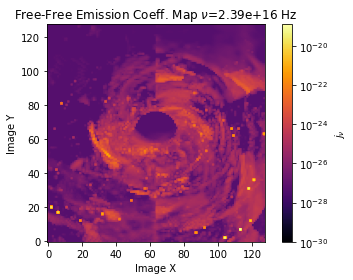

In [4]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['emission'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-60
i[i<minVal]=minVal

plt.imshow(i*(2.39e16)**2,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-30))
plt.colorbar(label="$j_\\nu$")
plt.title('Free-Free Emission Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

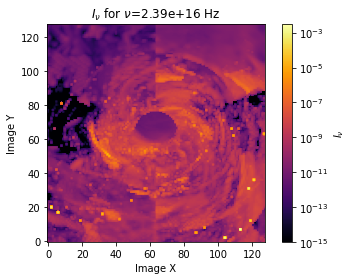

In [5]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-15
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('$I_\\nu$ for $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

the above image looks really ugly. I think that I should zoom out even more and also I should try to check different phi values/inc values. in particular it seems like the boundary out in front is weird.

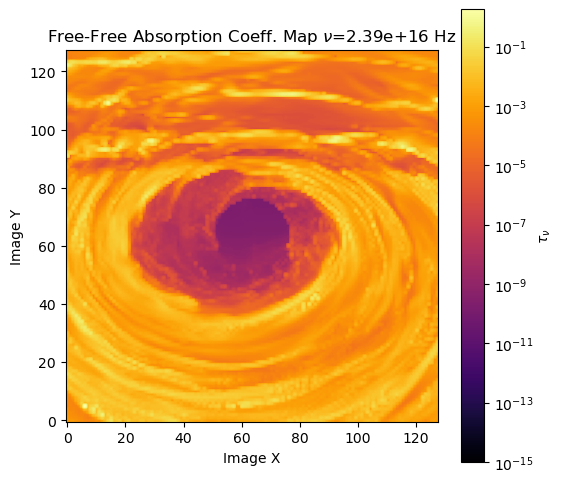

In [11]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['tau'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-15
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$\\tau_\\nu$")
plt.title('Free-Free Absorption Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

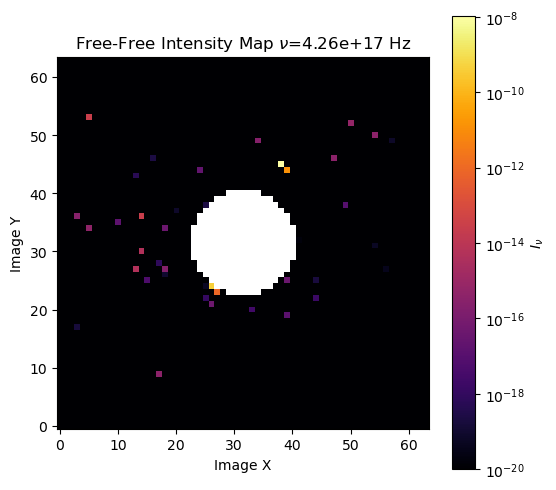

In [49]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

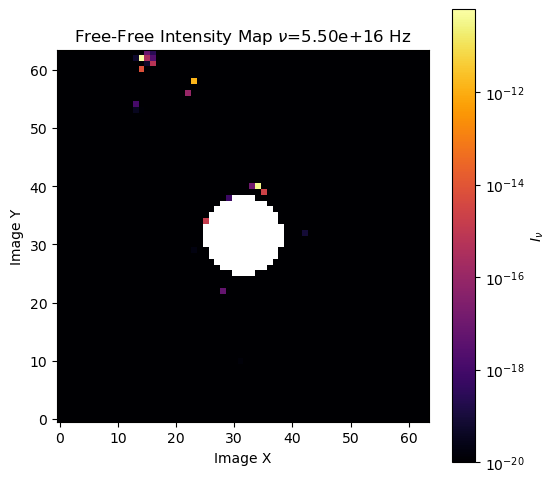

In [22]:
frequencies = np.array(hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

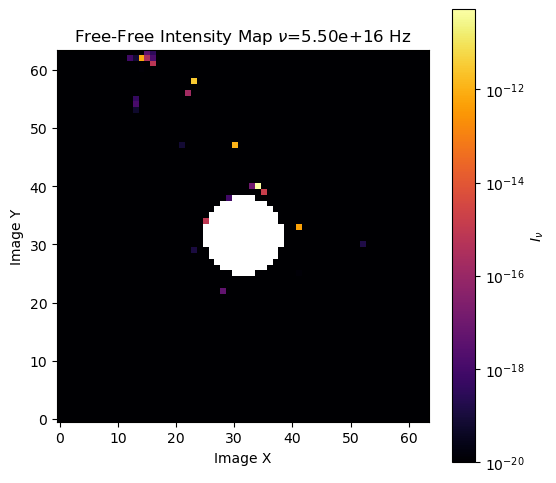

In [15]:
frequencies = np.array(r2hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(r2hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

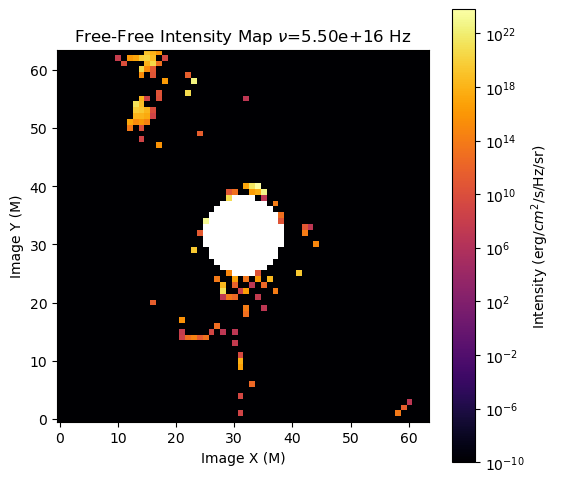

In [38]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

In [48]:
freq = len(frequencies)-3
print(np.nanmean(i))
print(np.nanmedian(i))

4.245919609251542e+21
1e-10


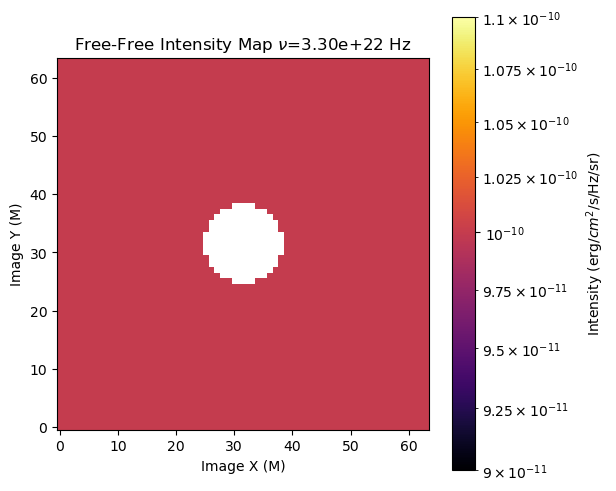

In [ ]:
freq = len(frequencies)-2
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

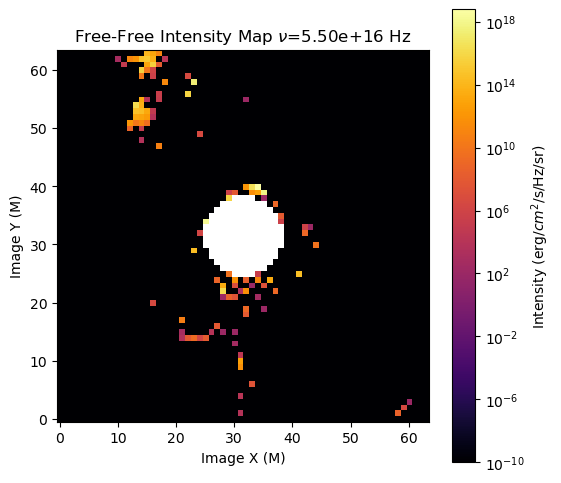

In [33]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(temp['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

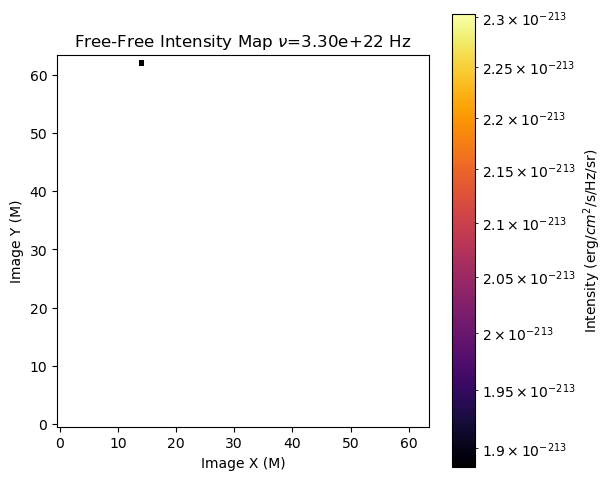

In [ ]:
for freq in range(len(frequencies)-1):
    plt.clf()
    plt.imshow(hf['I_nu'][freq],cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm())
    plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
    plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
    plt.xlabel('Image X (M)')
    plt.ylabel('Image Y (M)')
    #plt.show()
    plt.savefig('../plots/free_free_image_{0:.2e}Hz.png'.format(frequencies[freq]))

/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:446: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:453: UserWarning: Warning: converting a masked element to nan.
  a_min = np.float64(newmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:458: UserWarning: Warning: converting a masked element to nan.
  a_max = np.float64(newmax)


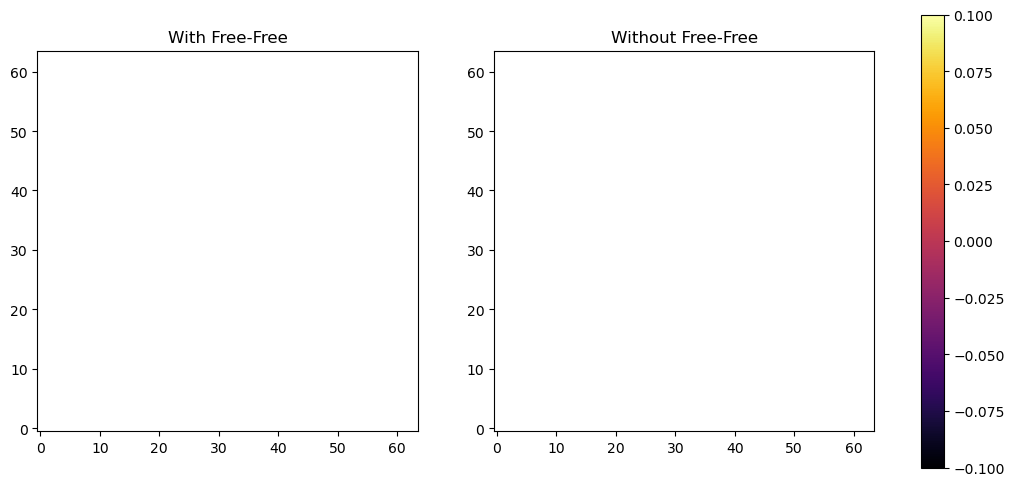

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(hf['I_nu'][15], cmap='inferno', origin='lower',vmax=1e15)
ax[1].imshow(hs['I_nu'][0], cmap='inferno', origin='lower',vmax=1e-3)
ax[0].set_title('With Free-Free')
ax[1].set_title('Without Free-Free')
plt.colorbar(ax[1].images[0], ax=ax, fraction=0.05)
plt.show()

In [24]:
free['I_nu'][32,32]

8.411915668450402e-08

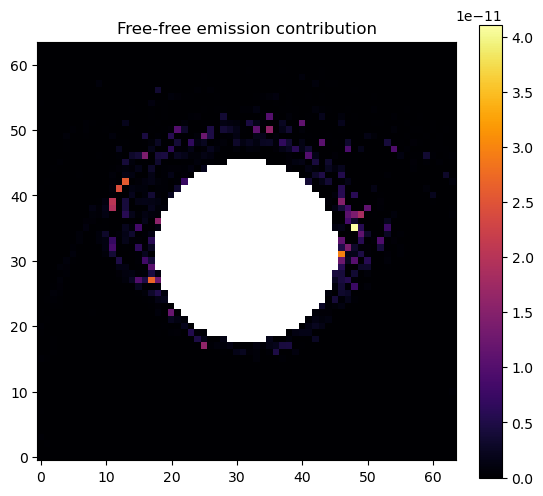

In [8]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['emission']-hs['emission'], cmap='inferno', origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Free-free emission contribution')
plt.show()

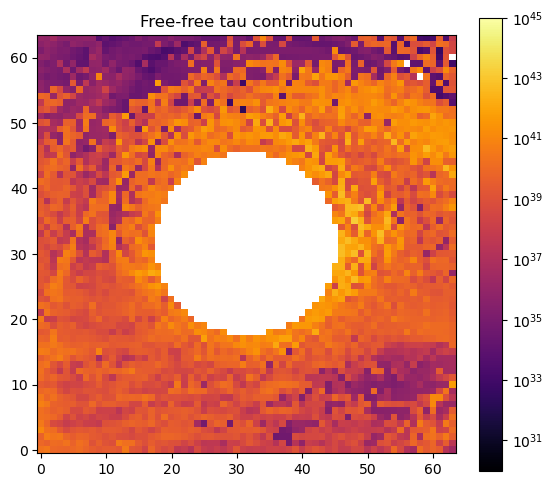

In [9]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['tau']-hs['tau'], cmap='inferno', origin='lower',norm=LogNorm(vmin=1e30, vmax=1e45))
plt.colorbar(fraction=0.05)
plt.title('Free-free tau contribution')
plt.show()

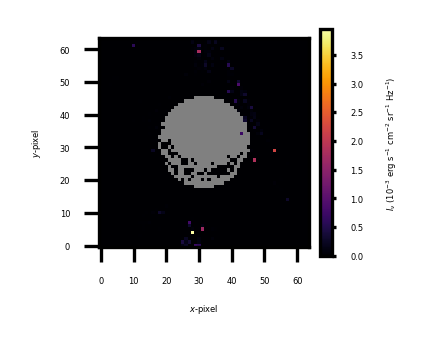

In [6]:
default_args['fontsize'] = (2)
default_args['figsize'] = (1,1)

fig,ax = utils.plot_data(**default_args)
#ax.margins(x=0,y=0)
plt.show()